In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import numpy as np 
import itertools
import  tensorflow
from tensorflow.keras.models import Model

In [2]:
import json, os, pickle, re, sys, cv2, itertools, shutil, random, glob, warnings, \
    IPython, numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.pylab as pylab, seaborn as sns
from keras import Input, Model
from keras.applications.imagenet_utils import preprocess_input
from keras.models import load_model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization,ZeroPadding2D, Conv2D, MaxPool2D, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

In [3]:
model_name = 'cnn.h5'
history_name = 'cnn_model.pkl'
train_path = '../input/suspicious-human-action/image_dataset/image/train'
test_path = '../input/suspicious-human-action/image_dataset/image/test'
classes_list = ['angry','fall','hit', 'jumping','lookingaround', 'run','smile', 'smoke','talk','throw','walk']
resized_img_shape = (64, 64, 3)

In [4]:
def plot_images(images_arr):
    fig, axes = plt.subplots(8, 8, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip( images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def plot_acc_and_loss(history):
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    epochs = range(1, len(loss)+1)

    plt.figure(figsize=(15,8))

    plt.subplot(121)
    plt.plot(epochs, acc, color='red', label='Training Accuracy')
    plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.xticks(epochs)
    plt.yticks(np.arange(0,1.1,0.1))
    plt.legend()

    plt.subplot(122)
    plt.plot(epochs, loss, color='orange', label='Training Loss')
    plt.plot(epochs, val_loss, color='navy', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.xticks(epochs)
    plt.legend()
    
def c_m_visualize(y_true, y_pred, labels, size, is_num_class=False, extra_r_c_label='precision_recall_accuracy', row_title='Target Class', col_title='Output Class', fig_title='Confusion Matrix', color_bar=False, color_map='YlGn', figsize=(10, 10)) -> np.array:
    """
    src: https://gist.github.com/rjarman/b2a5e00e65ba22554f2d1f4a07fc9532#file-c_m_visualization-py
    y_true: test classes
    y_pred: predicted classes
    labels: list of labels
    size: size of y_true or y_pred
    is_num_class: It indicates that whether a heatmap generates depends on numbers of classes or percentages
    extra_r_c_label: extra column and row label for precision, recall, support and accuracy as a str
    row_title: horizontal title of the figure
    col_title: verticle title of the figure
    fig_title: title of the figure
    color_bar: False means there will be no color bar attached to the figure and vice versa
    color_map: supported color map for sns.heatmap
    figsize: size of the figure
    
    return: confusion matrix as numpy.ndarray

    Examle:
    labels = ['Potato__Early_blight', 'Potato__Late_blight', 'Potato__healthy', 'Tomato__Early_blight', 'Tomato__Late_blight', 'Tomato__healthy']
    c_m_visualize(y_true, y_pred, labels, len(y_true))
    c_m_visualize(y_true, y_pred, labels, len(y_true), is_num_class=True)
    """
    params = {
        'figure.figsize': figsize,
        'axes.titleweight': 'bold',
        'axes.labelsize': '16',
        'axes.titlesize':'20',
        'axes.labelweight':'bold',
        'xtick.labelsize':'14',
        'ytick.labelsize':'14',
        'font.size': '14'
    }
    pylab.rcParams.update(params)
    
    labels = list(labels)
    c_m = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=list(range(len(labels))))
    c_m_ret = np.array(c_m)
    
    c_m_sum = np.sum(c_m, axis=1, keepdims=True)
    prediction_rate = c_m / c_m_sum.astype(float) * 100
    row_wise_sum = c_m.sum(axis=0)
    col_wise_sum = c_m.sum(axis=1)
    total_true_pos = c_m.diagonal()
    
    accuracy = total_true_pos.sum() / size * 100
    precision = total_true_pos / col_wise_sum * 100
    recall = total_true_pos / row_wise_sum * 100

    annotation = np.empty_like(c_m).astype(str)
    rows, cols = c_m.shape

    for i in range(rows):
        for j in range(cols):
            count = c_m[i, j]
            pre = prediction_rate[i, j]
            annotation[i, j] = '%d\n%.1f%%' % (count, pre)

    col_wise_sum = np.append(col_wise_sum, total_true_pos.sum())
    precision = np.append(precision, accuracy)

    recall = np.array([[i, j] for i,j in zip(row_wise_sum, recall)])
    precision = np.array([[i, j] for i,j in zip(col_wise_sum, precision)])

    annotation = np.concatenate((annotation, [list(map(lambda data: '%d\n%.1f%%' % (data[0], data[1]), recall))]), axis=0)
    annotation = np.concatenate((annotation, np.array([list(map(lambda data: '%d\n%.1f%%' % (data[0], data[1]), precision))]).T), axis=1)

    labels.append(extra_r_c_label)

    c_m = np.concatenate((c_m, [recall[:, 0]]), axis=0) if is_num_class else np.concatenate((c_m, [recall[:, 1]]), axis=0)
    c_m = np.concatenate((c_m, np.array([precision[:, 0]]).T), axis=1) if is_num_class else np.concatenate((c_m, np.array([precision[:, 1]]).T), axis=1)

    c_m = pd.DataFrame(c_m, index=labels, columns=labels)
    c_m.index.name = col_title
    c_m.columns.name = row_title

    heatmap = sns.heatmap(c_m, annot=annotation, fmt='', cbar=color_bar, cmap=color_map)
    heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
    plt.title(fig_title)
    plt.show()
    return c_m_ret

In [5]:
class Callback_(Callback):
 def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')==1.00):
      print("\nReached 100% accuracy so cancelling training!")
      self.model.stop_training = True

def train_acc(_model): return _model.evaluate(train_batches)

def get_model(epochs=1, is_save=False):
    _history_loss_acc_path = '../input/kermany2018/' + history_name if os.path.exists('../input/kermany2018/' + history_name) else './' + history_name
    _model_path = '../input/kermany2018/' + model_name if os.path.exists('../input/kermany2018/' + model_name) else './' + model_name
    global model_path 
    model_path = _model_path
    if is_save: 
        try: 
            os.remove(_history_loss_acc_path)
            os.remove(_model_path)
        except: pass
    def get_loss_acc(_model): return _model.evaluate(test_batches)
    if os.path.exists(_model_path) and os.path.exists(_history_loss_acc_path): 
        with open(_history_loss_acc_path, 'rb') as _file:
            _ = pickle.load(_file)
        model = load_model(_model_path)
        history, loss, acc = _['history'], _['loss'], _['accuracy']
        return model, history, loss, acc
    
    #input_shape = resized_img_shape
    input_shape = (64, 64, 3)
    
    
    model = tf.keras.models.Sequential([
                         tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides=(1,1), padding='valid',activation= 'relu', input_shape=input_shape),
                         tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
                         tf.keras.layers.Flatten(),
                         tf.keras.layers.Dense(units=128, activation='relu'),
                         tf.keras.layers.Dense(units=11, activation='softmax')
])

   

    """
    This is the pretrained transfer learning model, fine tuned with imagenet
    """
    
#     model=VGG16(
#         include_top=False,
#         weights="imagenet",
#         input_tensor=None,
#         input_shape=input_shape,
#         pooling=None,
# #         classes=12,
#         classes=4,
#         classifier_activation="softmax",
#     )
#     model.trainable = False
#     inputs = Input(shape=input_shape)
#     x = model(inputs, training=False)
#     x = Flatten()(x)
#     x = Dense(12, activation="relu")(x)
# #     x = Dense(50, activation="relu")(x)
# #     x = Dense(12, activation="softmax")(x)
#     x = Dense(4, activation="softmax")(x)
#     model = Model(inputs, x)

    model.summary()
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x=train_batches,
        steps_per_epoch=len(train_batches),
        validation_data=test_batches,
        validation_steps=len(test_batches),
        epochs=epochs,
        callbacks = [Callback_()],
        verbose=2
    )
    loss, acc = get_loss_acc(model)
    if is_save: 
        with open(_history_loss_acc_path, 'wb') as _file:
            pickle.dump({
                'history': history.history,
                'loss': loss,
                'accuracy': acc
            }, _file)
        model.save(_model_path)
    return model, history.history, loss, acc

In [6]:
def predict(img, model):
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x)
    return preds

def get_key(val):
    for key, value in test_batches.class_indices.items():
         if val == value: return key
    return "key doesn't exist"

Found 37082 images belonging to 11 classes.
Found 13965 images belonging to 11 classes.
{'angry': 0, 'fall': 1, 'hit': 2, 'jumping': 3, 'lookingaround': 4, 'run': 5, 'smile': 6, 'smoke': 7, 'talk': 8, 'throw': 9, 'walk': 10}


Train Images


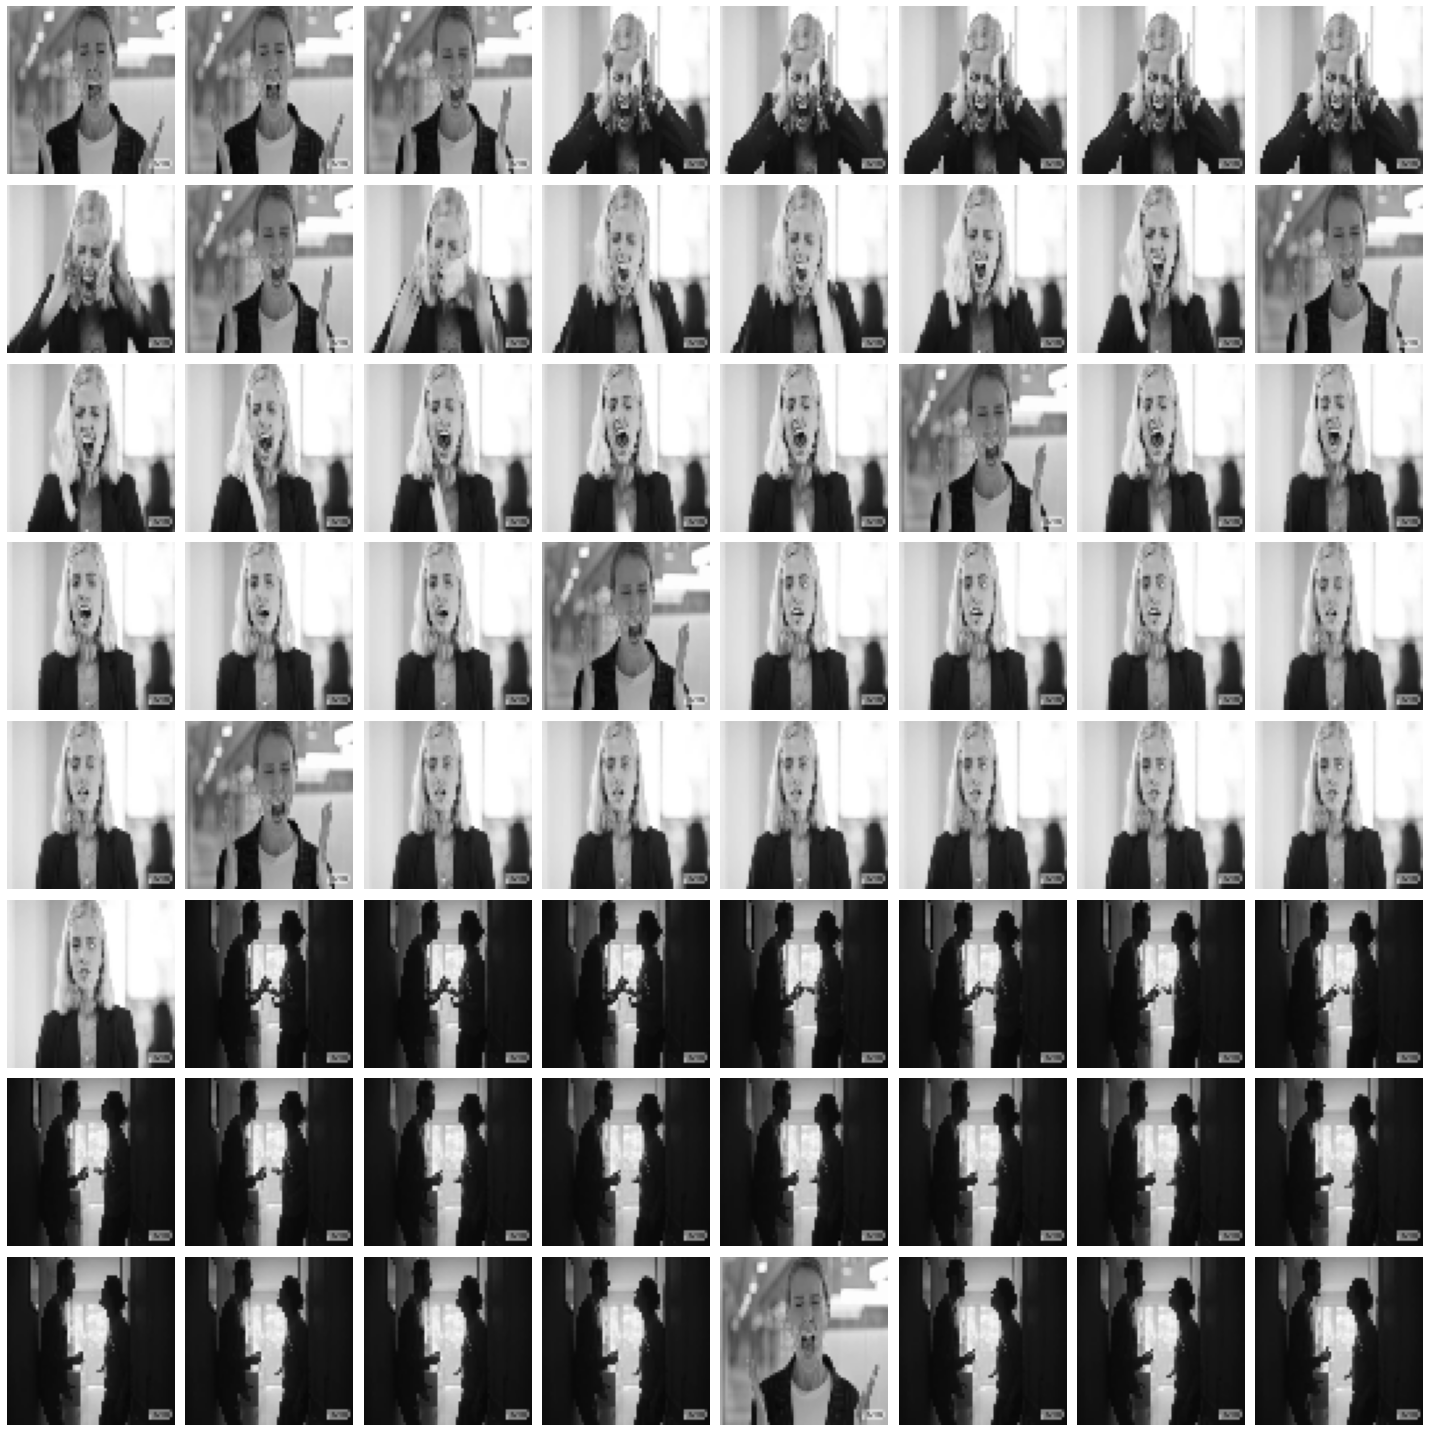



Test Images


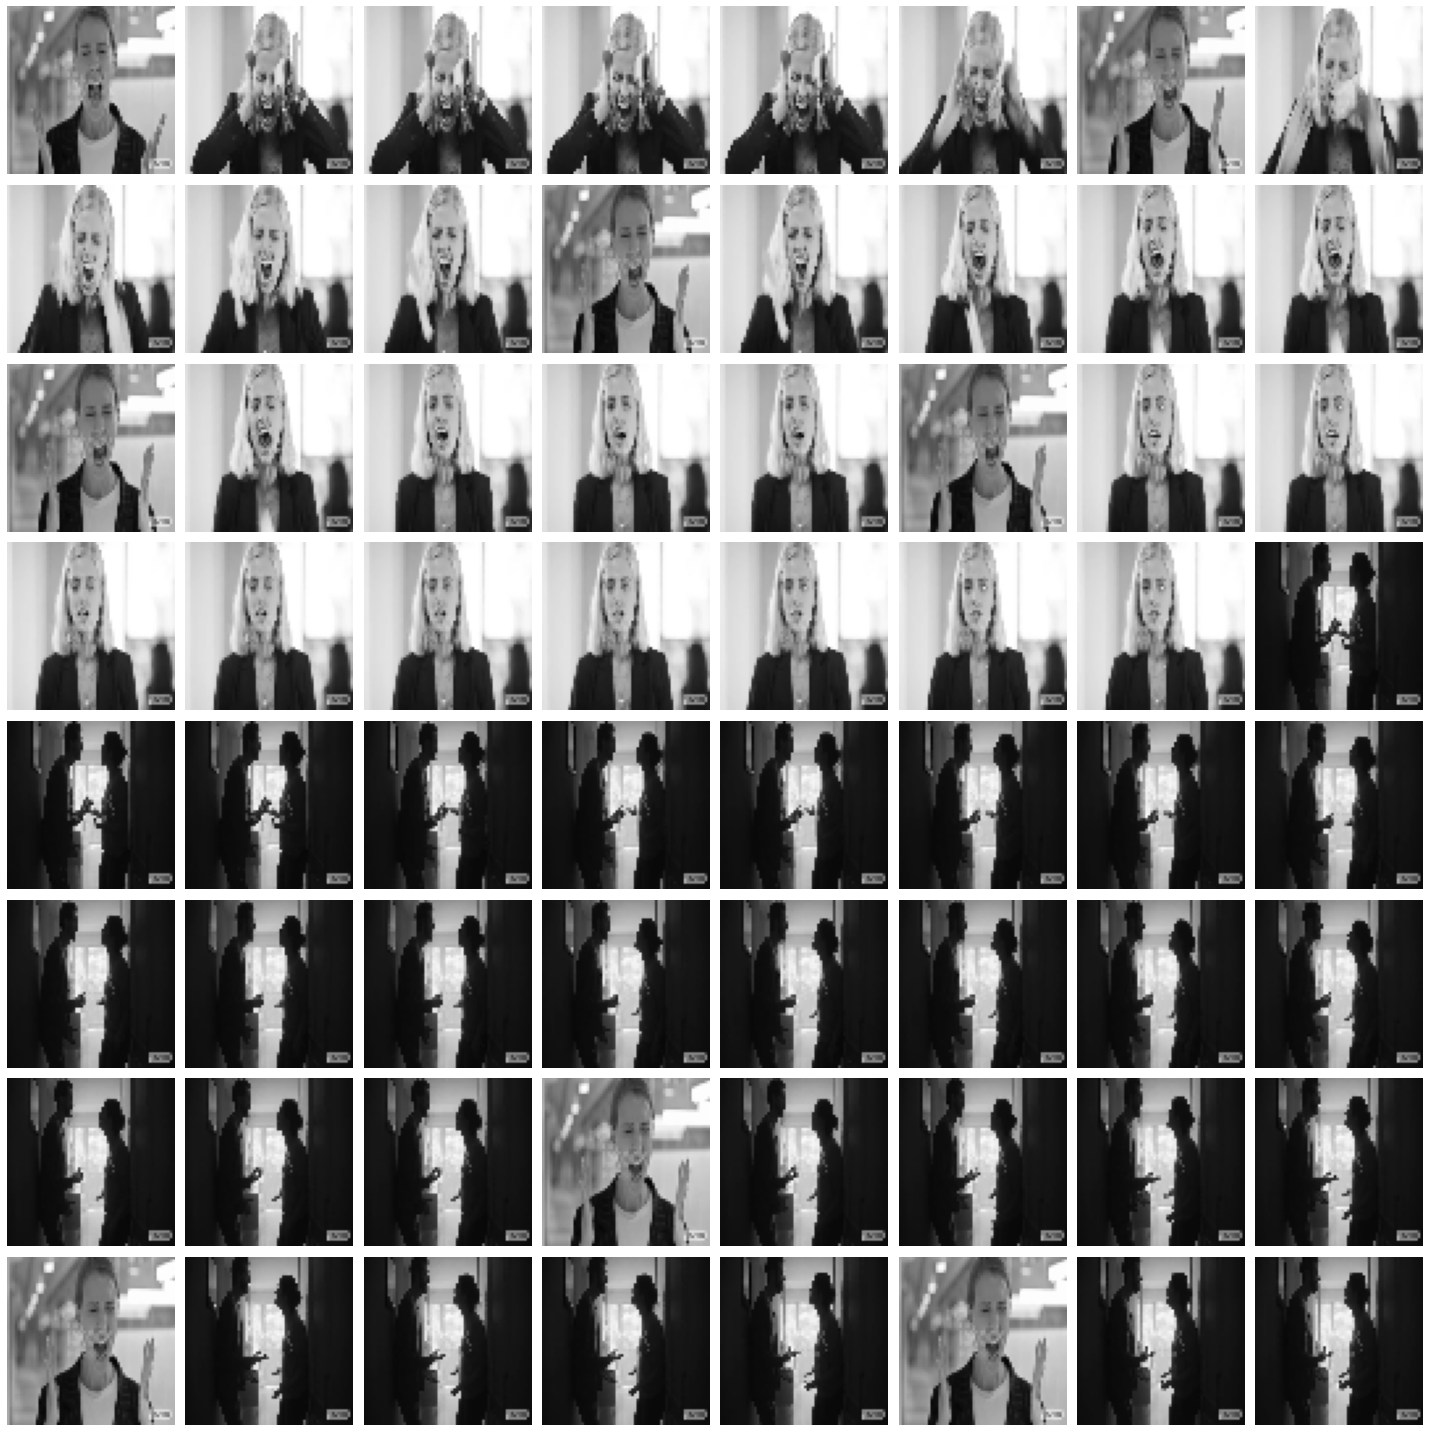

In [7]:


train_batches =ImageDataGenerator(rescale = 1/255) \
 .flow_from_directory(directory = '../input/suspicious-human-action/image_dataset/image/train', target_size = resized_img_shape[:2], classes = classes_list, batch_size = 64, shuffle = False)
test_batches =ImageDataGenerator(rescale = 1/255) \
.flow_from_directory(directory = '../input/suspicious-human-action/image_dataset/image/test', target_size = resized_img_shape[:2], classes = classes_list, batch_size = 64, shuffle = False)
print(train_batches.class_indices)
print('\n\nTrain Images')
plot_images(next(train_batches)[0])
print('\n\nTest Images')
plot_images(next(test_batches)[0])
#preprocessing_function = preprocess_inpu

2022-02-05 18:45:48.164233: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-05 18:45:48.256091: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-05 18:45:48.256790: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-05 18:45:48.258212: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 62, 62, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 31, 31, 32)        0         
_________________________________________________________________
flatten (Flatten)            (None, 30752)             0         
_________________________________________________________________
dense (Dense)                (None, 128)               3936384   
_________________________________________________________________
dense_1 (Dense)              (None, 11)                1419      
Total params: 3,938,699
Trainable params: 3,938,699
Non-trainable params: 0
_________________________________________________________________


2022-02-05 18:45:50.814796: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/15


2022-02-05 18:45:52.525456: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


580/580 - 397s - loss: 2.3837 - accuracy: 0.1418 - val_loss: 2.1630 - val_accuracy: 0.2412
Epoch 2/15
580/580 - 274s - loss: 2.1131 - accuracy: 0.2899 - val_loss: 2.2330 - val_accuracy: 0.2354
Epoch 3/15
580/580 - 282s - loss: 1.8563 - accuracy: 0.4059 - val_loss: 1.4432 - val_accuracy: 0.6092
Epoch 4/15
580/580 - 248s - loss: 1.5853 - accuracy: 0.5057 - val_loss: 1.2277 - val_accuracy: 0.6626
Epoch 5/15
580/580 - 231s - loss: 1.3562 - accuracy: 0.6074 - val_loss: 0.9723 - val_accuracy: 0.7849
Epoch 6/15
580/580 - 230s - loss: 1.1285 - accuracy: 0.6724 - val_loss: 0.8701 - val_accuracy: 0.7789
Epoch 7/15
580/580 - 273s - loss: 0.9825 - accuracy: 0.7114 - val_loss: 0.6829 - val_accuracy: 0.8576
Epoch 8/15
580/580 - 280s - loss: 0.8422 - accuracy: 0.7596 - val_loss: 0.5975 - val_accuracy: 0.8605
Epoch 9/15
580/580 - 268s - loss: 0.7468 - accuracy: 0.7922 - val_loss: 0.5141 - val_accuracy: 0.8502
Epoch 10/15
580/580 - 255s - loss: 0.6395 - accuracy: 0.8341 - val_loss: 0.4325 - val_accurac

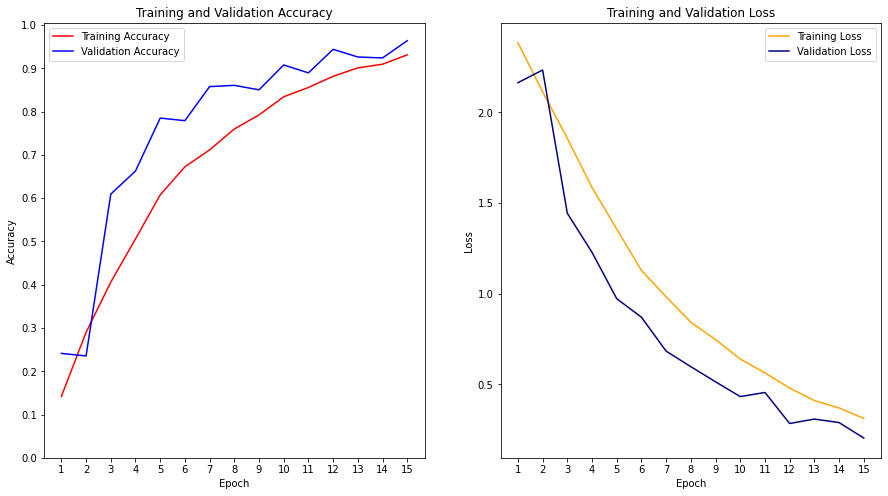

In [8]:
model, history, test_loss, test_accuracy =  get_model(epochs=15, is_save=True)
train_loss, train_accuracy = train_acc(model)
predictions = model.predict(x=test_batches, steps=len(test_batches), verbose=0)

if history: plot_acc_and_loss(history)
    
print("Test Accuracy: ",round(test_accuracy,3))
print("Test Loss: ",round(test_loss,3))
print("Train Accuracy: ",round(train_accuracy,3))
print("Train Loss: ",round(train_loss,3))

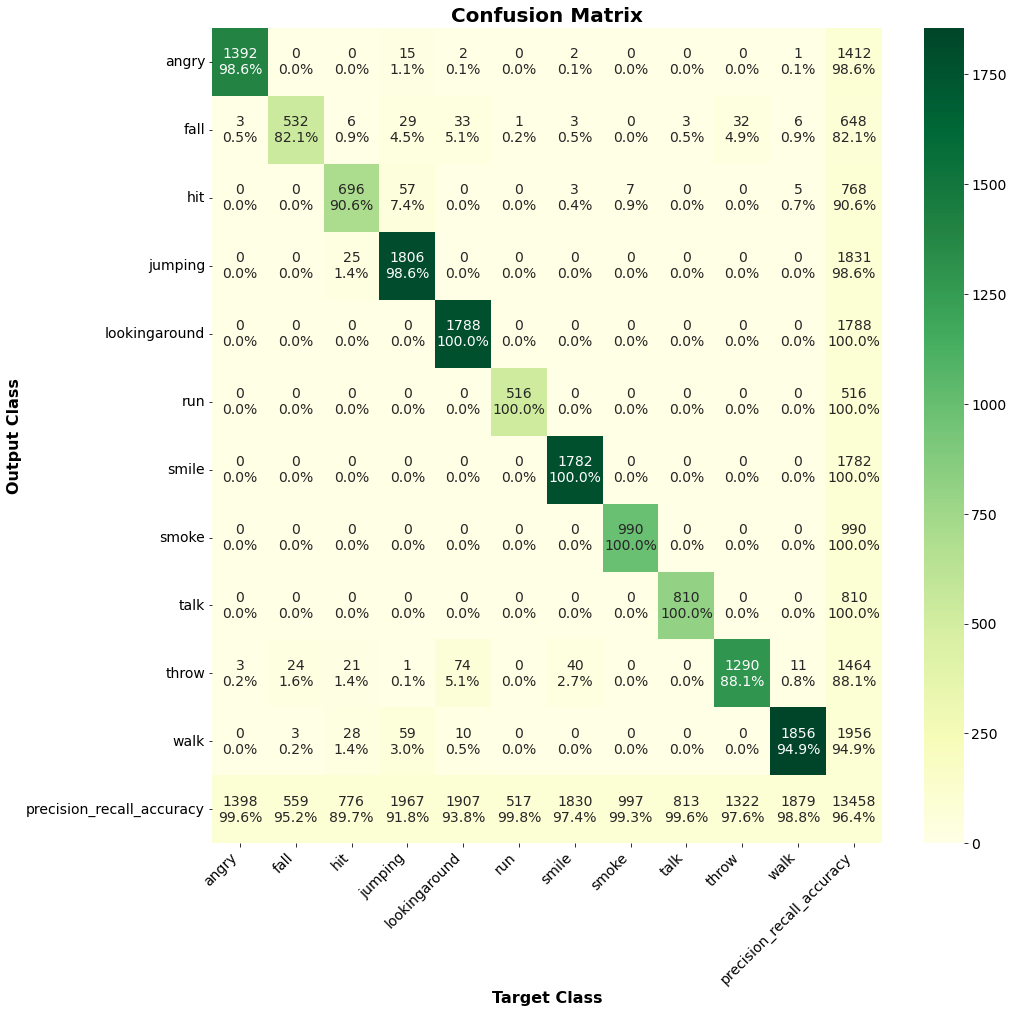

In [9]:
if len(test_batches.classes) == len(np.argmax(predictions, axis=-1)): 
    c_m_visualize(test_batches.classes, np.argmax(predictions, axis=-1), classes_list, len(test_batches.classes), color_bar=True, figsize=(15, 15))
else: print('classes does not match')

In [10]:
print(classification_report(test_batches.classes, np.argmax(predictions, axis=-1), labels=list(range(len(classes_list))), target_names=classes_list))

               precision    recall  f1-score   support

        angry       1.00      0.99      0.99      1412
         fall       0.95      0.82      0.88       648
          hit       0.90      0.91      0.90       768
      jumping       0.92      0.99      0.95      1831
lookingaround       0.94      1.00      0.97      1788
          run       1.00      1.00      1.00       516
        smile       0.97      1.00      0.99      1782
        smoke       0.99      1.00      1.00       990
         talk       1.00      1.00      1.00       810
        throw       0.98      0.88      0.93      1464
         walk       0.99      0.95      0.97      1956

     accuracy                           0.96     13965
    macro avg       0.97      0.96      0.96     13965
 weighted avg       0.96      0.96      0.96     13965



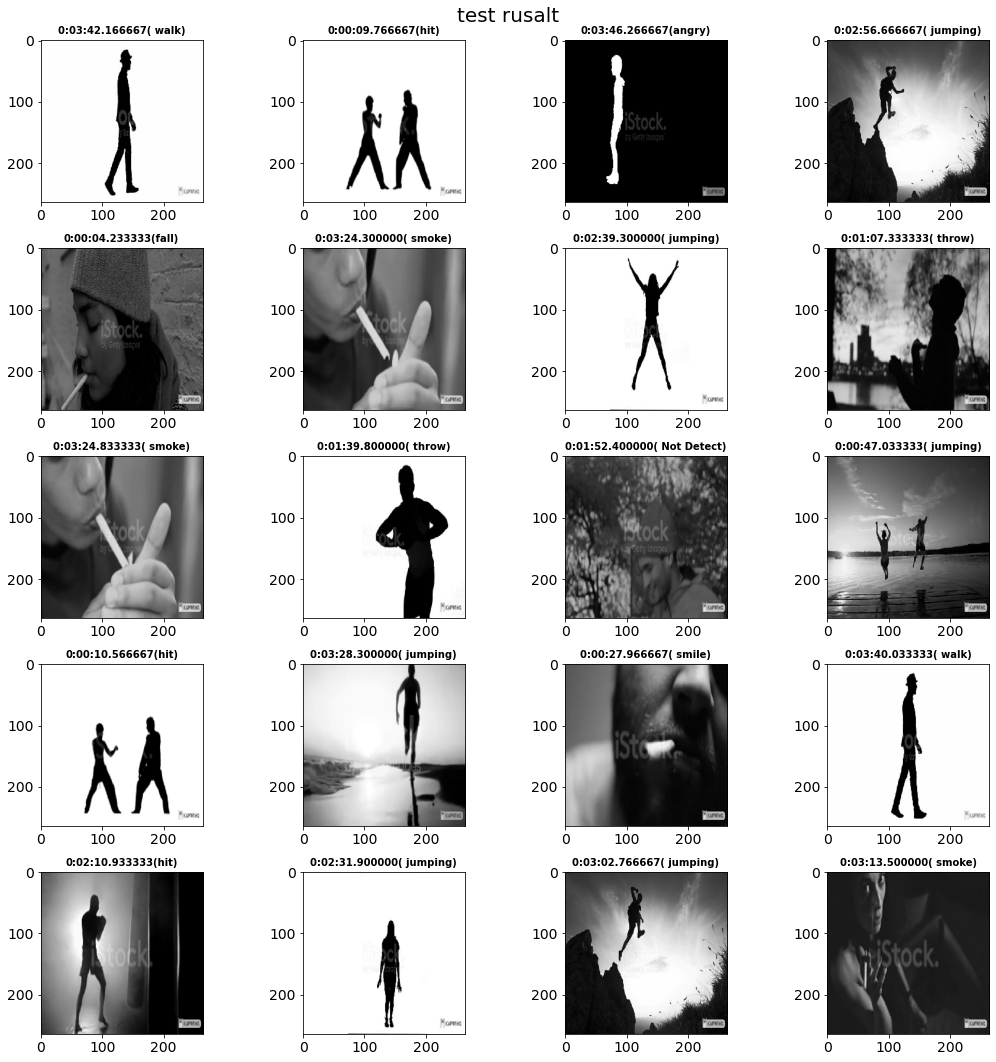

In [11]:
# Only Rusalt show 
from keras.preprocessing import image
import numpy as np
import  tensorflow
from tensorflow.keras.models import Model
from numpy.lib.shape_base import column_stack
import os 
import cv2
import pandas as pd

import os.path
import datetime
from random import randint
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':10})

width=5
height=5
rows = 5
cols = 4
axes=[]
fig=plt.figure()
for a in range(rows*cols):
    random=1
    for x in range(1,20):
        random=randint(1,6950  )
        duration=random/30; 
        # time_string=secs2hms(duration)
        base_dir = '../input/validation050/frame1/frame' + str(random) + '.jpg'
        time=str(datetime.timedelta(seconds=duration))
      
    
        file_exists = os.path.exists(base_dir)
      

        if file_exists==1:
            
            img=image.load_img(base_dir,target_size=(64, 64))

            #'angry': 0, 'fall': 1, 'hit': 2, 'jumping': 3, 'lokkingaround': 4, 'run': 5, 'smile': 6, 'smoke': 7, 'talk': 8, 'throw': 9, 'walk': 10
           # plt.imshow(img)
           # plt.show()
            h=[]
            X=image.img_to_array(img)
            X=np.expand_dims(X,axis=0)
            images=np.vstack([X])
            result=model.predict(images)
            if result[0][0]==1:
                    h="angry"
            elif    result[0][1]==1:
                    h="fall"
            elif    result[0][2]==1:
                    h="hit"    
            elif    result[0][3]==1:
                    h=" jumping"  
            elif    result[0][4]==1:
                    h=" lokkingaround" 
            elif    result[0][5]==1:
                    h=" run" 
            elif    result[0][6]==1:
                    h=" smile" 
            elif    result[0][7]==1:
                    h=" smoke" 
            elif    result[0][8]==1:
                    h=" talk"
            elif    result[0][9]==1:
                    h=" throw"
            elif    result[0][10]==1:
                    h=" walk"
            else :   
                   h=" Not Detect"  
                    
        elif file_exists==0:
                
                continue
      
        img=image.load_img(base_dir,target_size=(264,264))
        axes.append( fig.add_subplot(rows, cols, a+1) )
        
        subplot_title =(time +"(" + h +")")
        fig.suptitle('test rusalt', fontsize=20)
         
        axes[-1].set_title(subplot_title, fontsize=10)  
        plt.imshow(img)
        break
fig.tight_layout()    
plt.show()

for img, labels in zip(*next(test_batches)):
    preds = predict(img, model)
    val, max_prob = 0, 0
    for i in range(len(preds[0])):
        if preds[0][i] >= max_prob:
            max_prob = preds[0][i]
            val = i

    print(f'Predicted: {get_key(val)}')
    for i in range(len(labels)):
        if labels[i] == 1:
            print(f'Actual: {get_key(i)}\n')
            break
